In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout,Activation

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import mean_absolute_error
import os

for dirname, _, filenames in os.walk('/Algorithm_Trading/Coin_Price'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
data = '/Algorithm_Trading/Coin_Price/coin_Ethereum.csv'
dataset = pd.read_csv(data)
chosen_col = 'Close'
print(len(dataset))
dataset.head()

2160


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Ethereum,ETH,2015-08-08 23:59:59,2.798810,0.714725,2.793760,0.753325,674188.0,4.548689e+07
1,2,Ethereum,ETH,2015-08-09 23:59:59,0.879810,0.629191,0.706136,0.701897,532170.0,4.239957e+07
2,3,Ethereum,ETH,2015-08-10 23:59:59,0.729854,0.636546,0.713989,0.708448,405283.0,4.281836e+07
3,4,Ethereum,ETH,2015-08-11 23:59:59,1.131410,0.663235,0.708087,1.067860,1463100.0,6.456929e+07
4,5,Ethereum,ETH,2015-08-12 23:59:59,1.289940,0.883608,1.058750,1.217440,2150620.0,7.364501e+07


In [6]:
dataset.tail()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
2155,2156,Ethereum,ETH,2021-07-02 23:59:59,2155.596496,2021.824808,2109.892677,2150.040364,3.179621e+10,2.505527e+11
2156,2157,Ethereum,ETH,2021-07-03 23:59:59,2237.567155,2117.590013,2150.835025,2226.114282,1.743336e+10,2.594475e+11
2157,2158,Ethereum,ETH,2021-07-04 23:59:59,2384.286857,2190.837703,2226.550382,2321.724112,1.878711e+10,2.706217e+11
2158,2159,Ethereum,ETH,2021-07-05 23:59:59,2321.922836,2163.041394,2321.922836,2198.582464,2.010379e+10,2.562978e+11
2159,2160,Ethereum,ETH,2021-07-06 23:59:59,2346.294874,2197.919385,2197.919385,2324.679449,2.089186e+10,2.710286e+11


In [3]:
split_row = len(dataset) - int(0.2 * len(dataset))
train_data = dataset.iloc[:split_row]
test_data = dataset.iloc[split_row:]

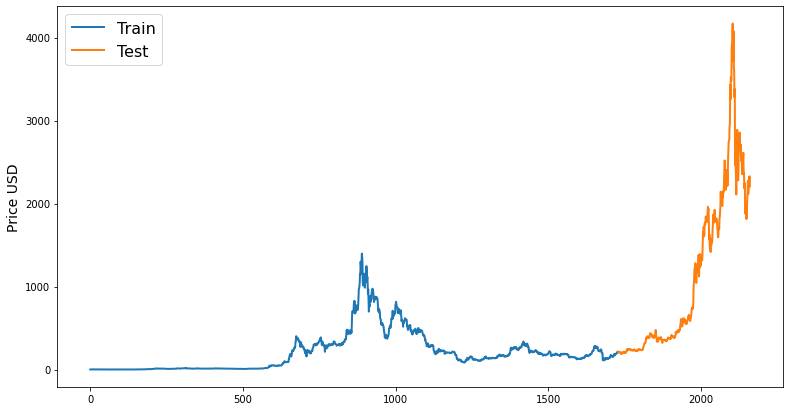

In [4]:
fig, ax = plt.subplots(1, figsize=(13, 7))
ax.plot(train_data[chosen_col], label='Train', linewidth=2)
ax.plot(test_data[chosen_col], label='Test', linewidth=2)
ax.set_ylabel('Price USD', fontsize=14)
ax.set_title('', fontsize=16)
ax.legend(loc='best', fontsize=16)

In [5]:
print(train_data[chosen_col].shape)

(1728,)


In [6]:
datacol = dataset.iloc[:, 7:8].values
traincol = train_data.iloc[:, 7:8].values
testcol = test_data.iloc[:, 7:8].values

shaped_data = np.reshape(datacol, (-1,1))
train_shaped = np.reshape(traincol, (-1,1))
test_shaped = np.reshape(testcol, (-1,1))

sc = MinMaxScaler(feature_range=(0,1))
sc.fit(shaped_data)

train_scaled_data = sc.transform(train_shaped)
test_scaled_data = sc.transform(test_shaped)

In [7]:
print(traincol.shape)

(1728, 1)


In [8]:
X = []
y = []
time_steps = 50

for i in range(time_steps, len(train_data)):
    X.append(train_scaled_data[i-time_steps:i,0])
    y.append(train_scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
model = Sequential()
model.add(LSTM(units=100, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))
model.add(Activation('linear'))
model.compile(optimizer='adam', loss='mse')

In [11]:
callback = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=1, callbacks=[callback], shuffle=True)

Epoch 1/100
42/42 [==============================] - 2s 29ms/step - loss: 7.3001e-04 - val_loss: 9.8049e-05
Epoch 2/100
42/42 [==============================] - 1s 20ms/step - loss: 1.6941e-04 - val_loss: 7.8404e-05
Epoch 3/100
42/42 [==============================] - 1s 19ms/step - loss: 1.2338e-04 - val_loss: 8.7833e-05
Epoch 4/100
42/42 [==============================] - 1s 21ms/step - loss: 1.1013e-04 - val_loss: 9.6756e-05
Epoch 5/100
42/42 [==============================] - 1s 20ms/step - loss: 9.1409e-05 - val_loss: 6.9025e-05
Epoch 6/100
42/42 [==============================] - 1s 20ms/step - loss: 1.0586e-04 - val_loss: 7.7294e-05
Epoch 7/100
42/42 [==============================] - 1s 22ms/step - loss: 1.1254e-04 - val_loss: 1.1129e-04
Epoch 8/100
42/42 [==============================] - 1s 22ms/step - loss: 1.0318e-04 - val_loss: 7.7873e-05
Epoch 9/100
42/42 [==============================] - 1s 22ms/step - loss: 8.4674e-05 - val_loss: 6.7092e-05
Epoch 10/100
42/42 [========

In [12]:
X_testing = []
y_testing = []

for i in range(time_steps, len(test_data)):
    X_testing.append(test_scaled_data[i-time_steps:i,0])
    y_testing.append(test_scaled_data[i, 0])

X_testing, y_testing = np.array(X_testing), np.array(y_testing)
X_testing = np.reshape(X_testing, (X_testing.shape[0], X_testing.shape[1], 1))

predicted_price = model.predict(X_testing)
inv_price = sc.inverse_transform(predicted_price)
real_price = np.reshape(y_testing, (-1,1))
real_price = sc.inverse_transform(real_price)

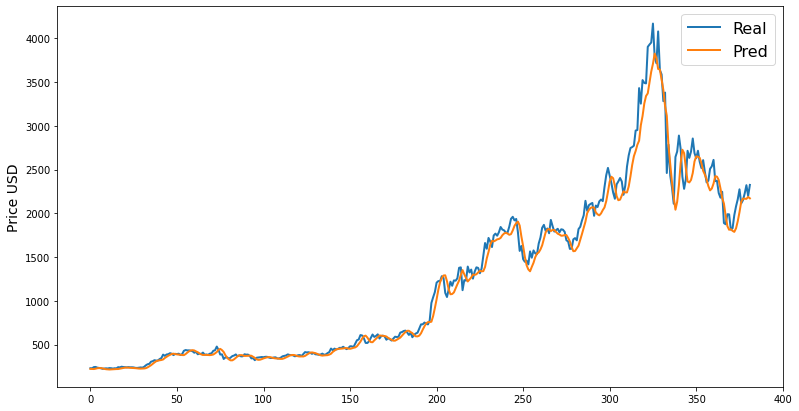

In [13]:
fig, ax = plt.subplots(1, figsize=(13, 7))
ax.plot(real_price, label='Real', linewidth=2)
ax.plot(inv_price, label='Pred', linewidth=2)
ax.set_ylabel('Price USD', fontsize=14)
ax.set_title('', fontsize=16)
ax.legend(loc='best', fontsize=16)

In [14]:
model.save("crypto_pred.h5")

In [15]:
from tensorflow import keras
new_model = keras.models.load_model('crypto_pred.h5')

In [18]:
data = '/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Bitcoin.csv'
dataset = pd.read_csv(data)
chosen_col = 'Close'
print(len(dataset))
split_row = len(dataset) - int(0.2 * len(dataset))
train_data = dataset.iloc[:split_row]
test_data = dataset.iloc[split_row:]
datacol = dataset.iloc[:, 7:8].values
traincol = train_data.iloc[:, 7:8].values
testcol = test_data.iloc[:, 7:8].values

shaped_data = np.reshape(datacol, (-1,1))
train_shaped = np.reshape(traincol, (-1,1))
test_shaped = np.reshape(testcol, (-1,1))

sc = MinMaxScaler(feature_range=(0,1))
sc.fit(shaped_data)

train_scaled_data = sc.transform(train_shaped)
test_scaled_data = sc.transform(test_shaped)
X = []
y = []
time_steps = 50

for i in range(time_steps, len(train_data)):
    X.append(train_scaled_data[i-time_steps:i,0])
    y.append(train_scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X_testing = []
y_testing = []

for i in range(time_steps, len(test_data)):
    X_testing.append(test_scaled_data[i-time_steps:i,0])
    y_testing.append(test_scaled_data[i, 0])

X_testing, y_testing = np.array(X_testing), np.array(y_testing)
X_testing = np.reshape(X_testing, (X_testing.shape[0], X_testing.shape[1], 1))
predicted_price = new_model.predict(X_testing)
inv_price = sc.inverse_transform(predicted_price)
real_price = np.reshape(y_testing, (-1,1))
real_price = sc.inverse_transform(real_price)

2991


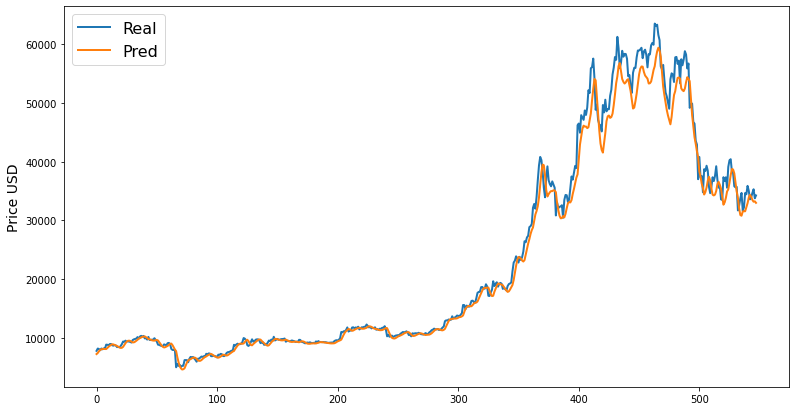

In [19]:
fig, ax = plt.subplots(1, figsize=(13, 7))
ax.plot(real_price, label='Real', linewidth=2)
ax.plot(inv_price, label='Pred', linewidth=2)
ax.set_ylabel('Price USD', fontsize=14)
ax.set_title('', fontsize=16)
ax.legend(loc='best', fontsize=16)

### Sharpe Ratio

In [34]:
Cryptos = ['bitcoin','bitcoin_cash','dash','ethereum','iota','litecoin','monero','nem','neo','numeraire','ripple','stratis','waves']

crypto_data = {}

crypto_data['bitcoin'] = pd.read_csv('/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Aave.csv', parse_dates=['Date'])
crypto_data['bitcoin_cash'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_BinanceCoin.csv", parse_dates=['Date'])
crypto_data['dash'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Bitcoin.csv", parse_dates=['Date'])
crypto_data['ethereum'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Cardano.csv", parse_dates=['Date'])
crypto_data['iota'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_ChainLink.csv", parse_dates=['Date'])
crypto_data['litecoin'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Cosmos.csv", parse_dates=['Date'])
crypto_data['monero'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_CryptocomCoin.csv", parse_dates=['Date'])
crypto_data['nem'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Dogecoin.csv", parse_dates=['Date'])
crypto_data['neo'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_EOS.csv", parse_dates=['Date'])
crypto_data['numeraire'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Ethereum.csv", parse_dates=['Date'])
crypto_data['ripple'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Iota.csv", parse_dates=['Date'])
crypto_data['stratis'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Litecoin.csv", parse_dates=['Date'])
crypto_data['waves'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Monero.csv", parse_dates=['Date'])
crypto_data['ethereum'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_NEM.csv", parse_dates=['Date'])
crypto_data['iota'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Polkadot.csv", parse_dates=['Date'])
crypto_data['litecoin'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Solana.csv", parse_dates=['Date'])
crypto_data['monero'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Stellar.csv", parse_dates=['Date'])
crypto_data['nem'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Tether.csv", parse_dates=['Date'])
crypto_data['neo'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Tron.csv", parse_dates=['Date'])
crypto_data['numeraire'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_Uniswap.csv", parse_dates=['Date'])
crypto_data['ripple'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_USDCoin.csv", parse_dates=['Date'])
crypto_data['stratis'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_WrappedBitcoin.csv", parse_dates=['Date'])
crypto_data['waves'] = pd.read_csv("/Users/Phoestia/Desktop/StoneLake/Algorithm_Trading/Coin_Price/coin_XRP.csv", parse_dates=['Date'])

In [42]:
df = pd.DataFrame(crypto_data[coin])

df.sample(100)

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
1155,1156,XRP,XRP,2016-10-03 23:59:59,0.008241,0.008065,0.008165,0.008089,2.776300e+06,2.869663e+08
2880,2881,XRP,XRP,2021-06-24 23:59:59,0.691010,0.617382,0.638590,0.672000,2.781916e+09,3.107631e+10
2720,2721,XRP,XRP,2021-01-15 23:59:59,0.301757,0.264747,0.295569,0.280405,4.955409e+09,1.273154e+10
2111,2112,XRP,XRP,2019-05-17 23:59:59,0.423509,0.366435,0.419676,0.386193,3.644156e+09,1.627160e+10
2150,2151,XRP,XRP,2019-06-25 23:59:59,0.473553,0.458875,0.470534,0.468229,1.958461e+09,1.993092e+10
...,...,...,...,...,...,...,...,...,...,...
833,834,XRP,XRP,2015-11-16 23:59:59,0.004237,0.004130,0.004163,0.004234,3.517250e+05,1.403970e+08
526,527,XRP,XRP,2015-01-13 23:59:59,0.020769,0.015599,0.018428,0.015648,3.113440e+06,4.847449e+08
1002,1003,XRP,XRP,2016-05-03 23:59:59,0.006717,0.006555,0.006716,0.006560,3.291250e+05,2.287385e+08
485,486,XRP,XRP,2014-12-03 23:59:59,0.013185,0.012918,0.013164,0.013130,1.063000e+06,4.054784e+08


In [43]:
df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,XRP,XRP,2013-08-05 23:59:59,0.005980,0.005613,0.005875,0.005613,0.0,4.387916e+07
1,2,XRP,XRP,2013-08-06 23:59:59,0.005661,0.004629,0.005637,0.004680,0.0,3.659101e+07
2,3,XRP,XRP,2013-08-07 23:59:59,0.004682,0.004333,0.004669,0.004417,0.0,3.453412e+07
3,4,XRP,XRP,2013-08-08 23:59:59,0.004424,0.004175,0.004397,0.004254,0.0,3.325863e+07
4,5,XRP,XRP,2013-08-09 23:59:59,0.004367,0.004253,0.004257,0.004291,0.0,3.354750e+07


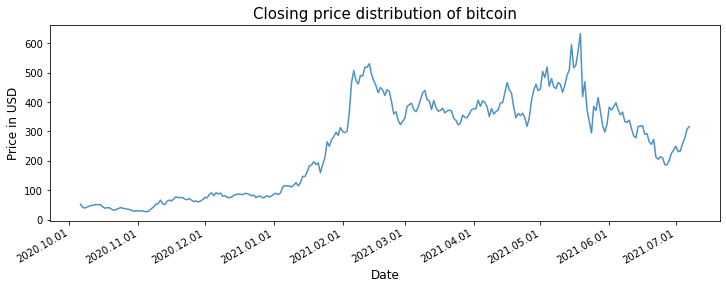

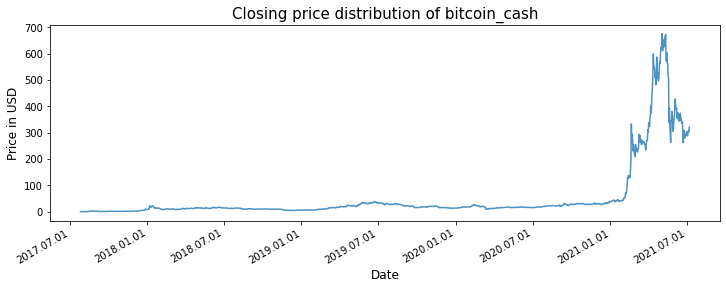

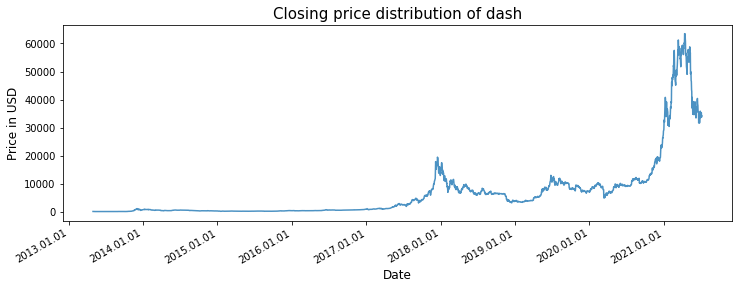

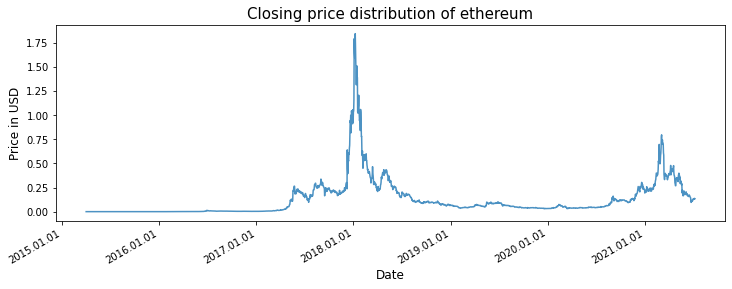

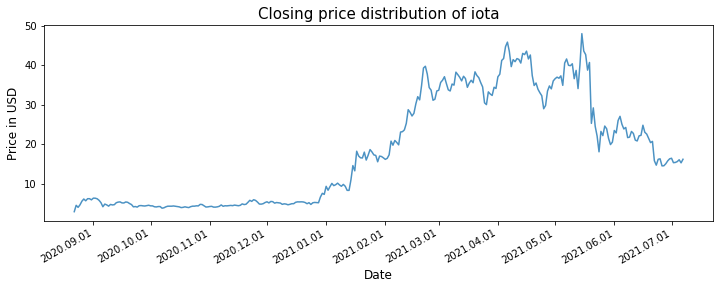

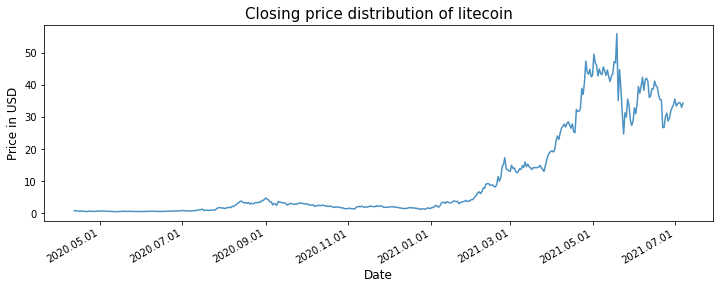

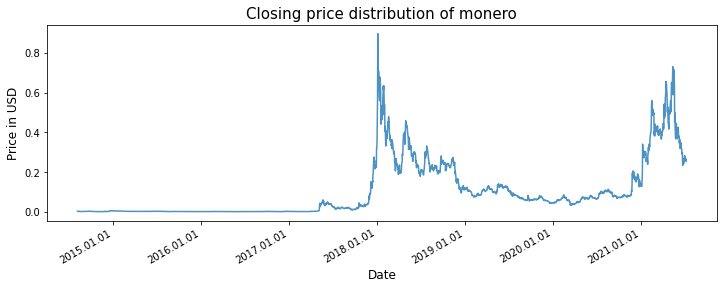

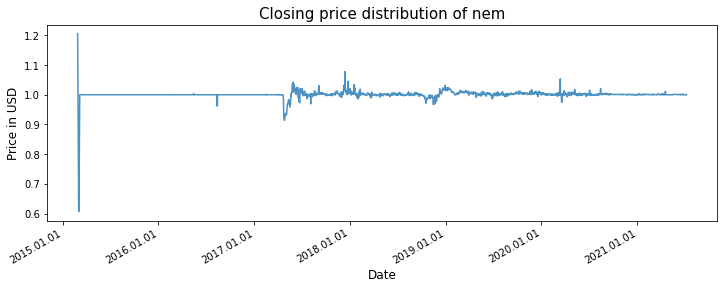

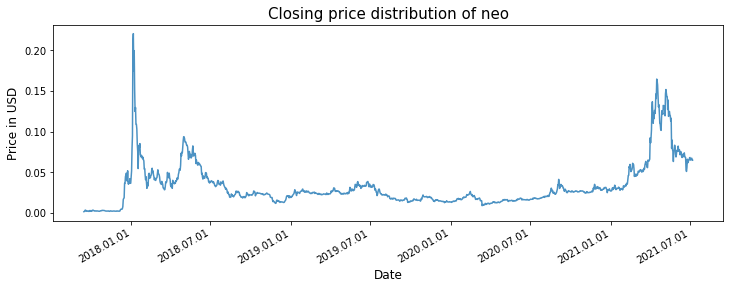

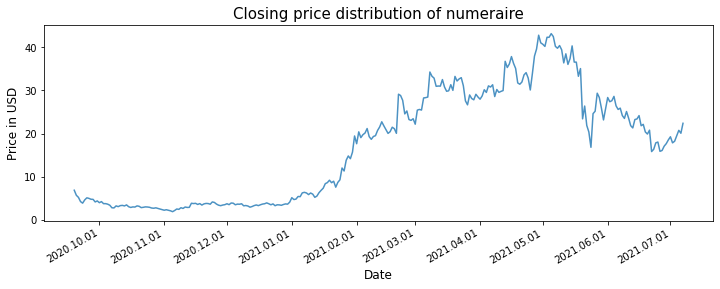

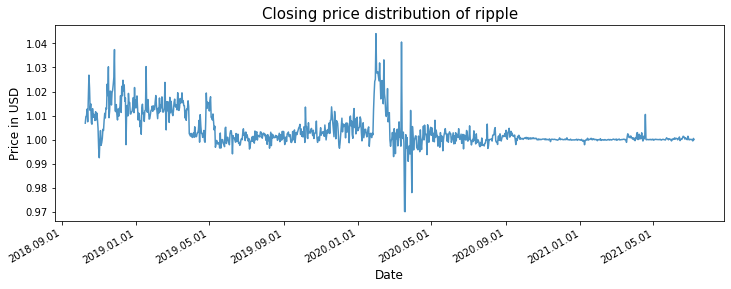

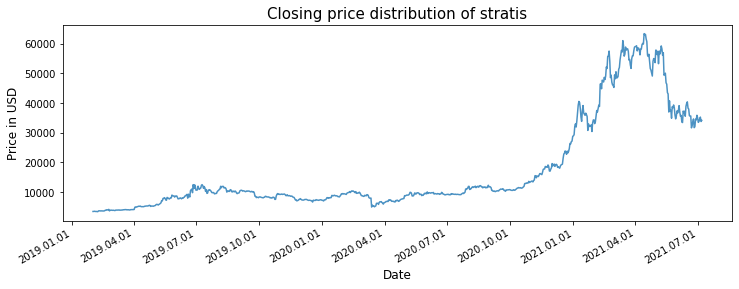

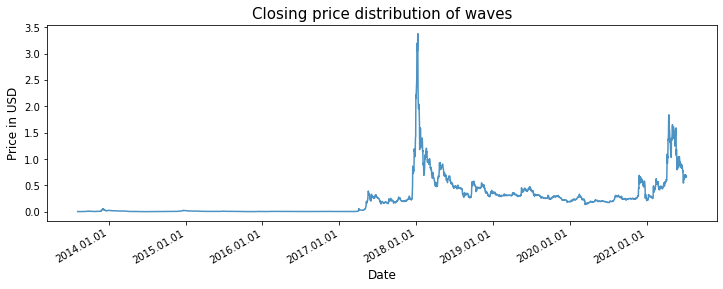

In [45]:
import matplotlib.dates as mdates
import seaborn as sns


for coin in crypto_data:
    df = pd.DataFrame(crypto_data[coin])
    df = df[['Date' , 'Close']]
    df['Date_mpl'] = df['Date'].apply(lambda x: mdates.date2num(x)) 
#     sns.FacetGrid(df, row="Close", col="Date", margin_titles=True)
    fig, ax = plt.subplots(figsize=(12,4))
    sns.lineplot(x=df['Date'], y = df.Close.values,  alpha=0.8,  ax=ax)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y.%m.%d'))
    fig.autofmt_xdate()
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price in USD', fontsize=12)
    title_str = "Closing price distribution of " + coin
    plt.title(title_str, fontsize=15)
    plt.show()

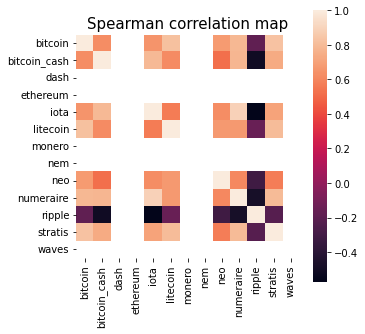

,bitcoin,bitcoin_cash,dash,ethereum,iota,litecoin,monero,nem,neo,numeraire,ripple,stratis,waves
bitcoin,1.000000,0.626515,NaN,NaN,0.650552,0.826820,NaN,NaN,0.676395,0.788065,-0.182149,0.831764,NaN
bitcoin_cash,0.626515,1.000000,NaN,NaN,0.794446,0.621574,NaN,NaN,0.522502,0.779151,-0.507924,0.741667,NaN
dash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethereum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iota,0.650552,0.794446,NaN,NaN,1.000000,0.565730,NaN,NaN,0.630233,0.892042,-0.573925,0.709666,NaN
litecoin,0.826820,0.621574,NaN,NaN,0.565730,1.000000,NaN,NaN,0.671594,0.668134,-0.153113,0.807130,NaN
monero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neo,0.676395,0.522502,NaN,NaN,0.630233,0.671594,NaN,NaN,1.000000,0.611289,-0.312929,0.573640,NaN
numeraire,0.788065,0.779151,NaN,NaN,0.892042,0.668134,NaN,NaN,0.611289,1.000000,-0.478710,0.802702,NaN


In [47]:
df = pd.DataFrame() 
currency_name = []
df['Date'] = crypto_data['bitcoin'].Date 
df = df[df['Date']>'2017-05-01']
for coin in crypto_data:
    currency_name.append(coin)
    temp_df = crypto_data[coin]
    df[coin] = temp_df[temp_df['Date']>'2017-05-01'].Close

temp_df = df[currency_name]
corrmat = temp_df.corr(method='spearman')
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corrmat, vmax=1., square=True)
plt.title("Spearman correlation map", fontsize=15)
plt.show()
temp_df.corr(method='spearman')

In [20]:
df.head()

,bitcoin,bitcoin_cash,dash,ethereum,iota,litecoin,monero,nem,neo,numeraire,ripple,stratis,waves
0,53.219243,0.105138,NaN,NaN,2.875028,0.776819,NaN,NaN,0.001427,6.897257,1.00686,3466.506533,NaN
1,42.401599,0.107737,NaN,NaN,4.484690,0.882507,NaN,NaN,0.001801,5.724464,1.00962,3480.772314,NaN
2,40.083976,0.104067,NaN,NaN,3.967066,0.777832,NaN,NaN,0.001831,5.244195,1.00978,3542.095361,NaN
3,43.764463,0.107811,NaN,NaN,4.602614,0.661925,NaN,NaN,0.003320,4.266079,1.01272,3477.866026,NaN
4,46.817744,0.106414,NaN,NaN,5.523393,0.646651,NaN,NaN,0.003263,3.905138,1.00743,3481.219346,NaN


Text(0, 0.5, 'daily returns')

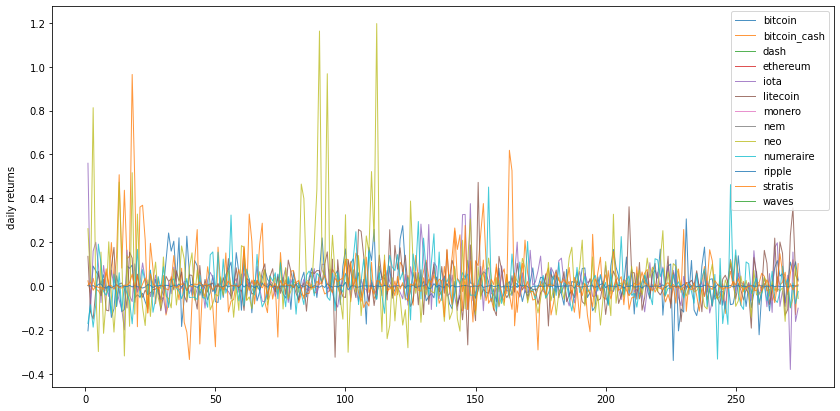

In [23]:
# Convert into Return
returns = df.pct_change()

plt.figure(figsize=(14, 7))
for c in returns.columns.values:
    plt.plot(returns.index, returns[c], lw=1, alpha=0.8,label=c)
plt.legend(loc='upper right', fontsize=10)
plt.ylabel('daily returns')

##### Random Portfolios Generation
Calculate the returns and std, and to make it as an annualized calculation we take into account 252 business days in one year

The convention for converting 1 day variance $\sigma^2_{day}$  to 1 year variance $\sigma^2_{year}$ is $$\sigma^2_{year}=\sigma^2_{day}\times 252$$
Equivalently, 
$$\sigma_{year}=\sigma_{day}\times \sqrt{252}$$
Here
$$\sigma^2_P=\alpha^\top \times \Sigma\times\alpha $$ 
$$\sigma_P=\sqrt{\sigma^2_P}$$
$$r_P=\alpha^\top\times {\bf r}$$
$$SR_P=\frac{r_P-r_f}{\sigma_P}$$

In [35]:
def portfolio_annualized_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns*weights )*252
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))*np.sqrt(252)
    return std, returns
  
def random_portfolios(num_portfolios, mean_returns, cov_matrix, risk_free_rate):
    results = np.zeros((3,num_portfolios))
    weights_record = []
    for i in range(num_portfolios):
        weights = np.random.random(len(Cryptos))
        weights /= np.sum(weights)  #make sure the sum is 1
        weights_record.append(weights)
        portfolio_std, portfolio_return = portfolio_annualized_performance(weights, mean_returns, cov_matrix)
        results[0,i] = portfolio_std
        results[1,i] = portfolio_return
        results[2,i] = (portfolio_return - risk_free_rate) / portfolio_std
    return results, weights_record

In [47]:
returns

0            NaN
1      -0.038328
2      -0.158345
3      -0.100692
4      -0.070906
          ...   
2986    0.009679
2987    0.022760
2988    0.017861
2989   -0.043692
2990    0.014496
Name: Close, Length: 2991, dtype: float64

In [25]:
mean_returns = returns.mean()
cov_matrix = returns.cov()
num_portfolios = 2500
risk_free_rate = 0.0178

In [26]:
mean_returns.round(4)

bitcoin         0.0102
bitcoin_cash    0.0263
dash               NaN
ethereum           NaN
iota            0.0110
litecoin        0.0097
monero             NaN
nem                NaN
neo             0.0248
numeraire       0.0079
ripple         -0.0000
stratis         0.0047
waves              NaN
dtype: float64

In [27]:
cov_matrix.round(6)

,bitcoin,bitcoin_cash,dash,ethereum,iota,litecoin,monero,nem,neo,numeraire,ripple,stratis,waves
bitcoin,0.007490,-0.000549,NaN,NaN,-0.000382,0.000347,NaN,NaN,0.000671,0.000184,-0.000010,0.000046,NaN
bitcoin_cash,-0.000549,0.018701,NaN,NaN,-0.000667,0.000099,NaN,NaN,0.000618,-0.000581,-0.000028,0.000394,NaN
dash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethereum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iota,-0.000382,-0.000667,NaN,NaN,0.007557,0.000300,NaN,NaN,0.000954,0.000035,-0.000022,-0.000029,NaN
litecoin,0.000347,0.000099,NaN,NaN,0.000300,0.008810,NaN,NaN,-0.000087,0.000345,0.000004,0.000075,NaN
monero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neo,0.000671,0.000618,NaN,NaN,0.000954,-0.000087,NaN,NaN,0.031910,-0.001649,0.000081,0.000693,NaN
numeraire,0.000184,-0.000581,NaN,NaN,0.000035,0.000345,NaN,NaN,-0.001649,0.008420,0.000021,-0.000087,NaN


In [28]:
returns.corr().round(6)

,bitcoin,bitcoin_cash,dash,ethereum,iota,litecoin,monero,nem,neo,numeraire,ripple,stratis,waves
bitcoin,1.000000,-0.046351,NaN,NaN,-0.050715,0.042701,NaN,NaN,0.043387,0.023202,-0.022191,0.011148,NaN
bitcoin_cash,-0.046351,1.000000,NaN,NaN,-0.056092,0.007676,NaN,NaN,0.025282,-0.046337,-0.040234,0.060912,NaN
dash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethereum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iota,-0.050715,-0.056092,NaN,NaN,1.000000,0.036789,NaN,NaN,0.061429,0.004351,-0.049299,-0.007095,NaN
litecoin,0.042701,0.007676,NaN,NaN,0.036789,1.000000,NaN,NaN,-0.005210,0.040102,0.008881,0.016890,NaN
monero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neo,0.043387,0.025282,NaN,NaN,0.061429,-0.005210,NaN,NaN,1.000000,-0.100586,0.087984,0.081997,NaN
numeraire,0.023202,-0.046337,NaN,NaN,0.004351,0.040102,NaN,NaN,-0.100586,1.000000,0.045472,-0.019985,NaN


In [48]:
df.columns

Index(['Date', 'bitcoin', 'bitcoin_cash', 'dash', 'ethereum', 'iota',
       'litecoin', 'monero', 'nem', 'neo', 'numeraire', 'ripple', 'stratis',
       'waves'],
      dtype='object')

In [31]:
def display_simulated_ef_with_random(mean_returns, cov_matrix, num_portfolios, risk_free_rate):
    results, weights = random_portfolios(num_portfolios,mean_returns, cov_matrix, risk_free_rate)
    
    max_sharpe_idx = np.argmax(results[2])
    sdp, rp = results[0,max_sharpe_idx], results[1,max_sharpe_idx]
    max_sharpe_allocation = pd.DataFrame(weights[max_sharpe_idx],index=df.columns,columns=['allocation'])
    max_sharpe_allocation.allocation = [round(i*100,2)for i in max_sharpe_allocation.allocation]
    max_sharpe_allocation = max_sharpe_allocation.T
    
    min_vol_idx = np.argmin(results[0])
    sdp_min, rp_min = results[0,min_vol_idx], results[1,min_vol_idx]
    min_vol_allocation = pd.DataFrame(weights[min_vol_idx],index=df.columns,columns=['allocation'])
    min_vol_allocation.allocation = [round(i*100,2)for i in min_vol_allocation.allocation]
    min_vol_allocation = min_vol_allocation.T
    
    print("-"*80)
    print("Maximum Sharpe Ratio Portfolio Allocation\n")
    print("Annualized Return:", round(rp,2))
    print("Annualized STD:", round(sdp,2))
    print("\n")
    print(max_sharpe_allocation)
    print("-"*80)
    print("Minimum STD Portfolio Allocation\n")
    print("Annualized Return:", round(rp_min,2))
    print("Annualized STD:", round(sdp_min,2))
    print("\n")
    print(min_vol_allocation)
    
    plt.figure(figsize=(12, 8))
    plt.scatter(results[0,:],results[1,:],c=results[2,:],cmap='YlGnBu', marker='o', s=10, alpha=0.3)
    plt.colorbar()
    plt.scatter(sdp,rp,marker='o',color='r',s=50, label='Maximum Sharpe ratio')
    plt.scatter(sdp_min,rp_min,marker='o',color='g',s=50, label='Minimum STD')
    plt.title('Simulated Portfolio Optimization based on Efficient Frontier')
    plt.xlabel('annualized STD')
    plt.ylabel('annualized returns')
    plt.legend(labelspacing=0.8)

--------------------------------------------------------------------------------
Maximum Sharpe Ratio Portfolio Allocation

Annualized Return: 1.87
Annualized STD: nan


            bitcoin  bitcoin_cash   dash  ethereum   iota  litecoin  monero  \
allocation    756.0        1440.0  771.0     812.0  929.0     554.0    54.0   

              nem   neo  numeraire  ripple  stratis   waves  
allocation  200.0  20.0     1228.0  1493.0    662.0  1080.0  
--------------------------------------------------------------------------------
Minimum STD Portfolio Allocation

Annualized Return: 1.87
Annualized STD: nan


            bitcoin  bitcoin_cash   dash  ethereum   iota  litecoin  monero  \
allocation    756.0        1440.0  771.0     812.0  929.0     554.0    54.0   

              nem   neo  numeraire  ripple  stratis   waves  
allocation  200.0  20.0     1228.0  1493.0    662.0  1080.0  


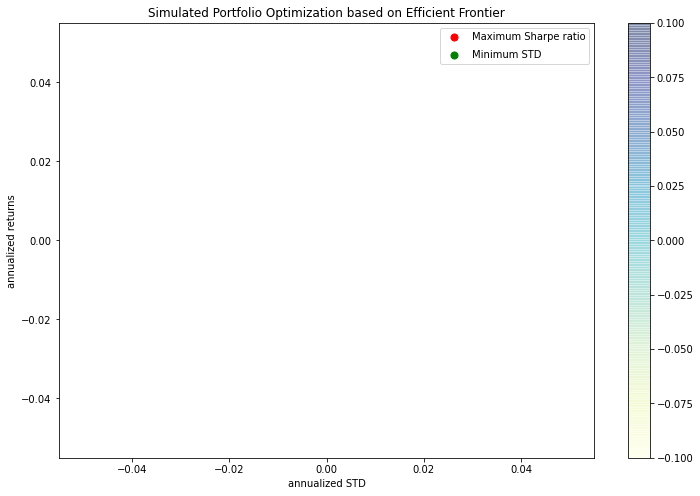

In [36]:
display_simulated_ef_with_random(mean_returns, cov_matrix, num_portfolios, risk_free_rate)